   # Team JM2 Classification Predict Student Solution

© Explore Data Science Academy

---
### Honour Code

We {**TEAM JM2**}, confirm - by submitting this document - that the solutions in this notebook are a result of my own work and that I abide by the [EDSA honour code](https://drive.google.com/file/d/1QDCjGZJ8-FmJE3bZdIQNwnJyQKPhHZBn/view?usp=sharing).

Non-compliance with the honour code constitutes a material breach of contract

### Predict Overview: Climate Change Belief Analysis 2022



Many companies are built around lessening one’s environmental impact or carbon footprint. They offer products and services that are environmentally friendly and sustainable, in line with their values and ideals. They would like to determine how people perceive climate change and whether or not they believe it is a real threat. This would add to their market research efforts in gauging how their product/service may be received.

With this context, EDSA is challenging you during the Classification Sprint with the task of creating a Machine Learning model that is able to classify whether or not a person believes in climate change, based on their novel tweet data.

Providing an accurate and robust solution to this task gives companies access to a broad base of consumer sentiment, spanning multiple demographic and geographic categories - thus increasing their insights and informing future marketing strategies.

<a id="cont"></a>

## Table of Contents

<a href=#one>1. Importing Packages</a>

<a href=#two>2. Loading Data</a>

<a href=#three>3. Pre-processing of the datasets</a>

<a href=#four>4. Exploratory Data Analysis (EDA)</a>

<a href=#five>5. Data Engineering</a>

<a href=#six>6. Modeling</a>

<a href=#seven>7. Model Performance</a>

<a href=#seven>8. Model Explanations</a>
<a href=#seven>9. Conclusion</a>

 <a id="one"></a>
## 1. Importing Packages
<a href=#cont>Back to Table of Contents</a>

---
    
| ⚡ Description: Importing Packages ⚡ |
| :--------------------------- |
| In this section we imported and briefly discussed the libraries that will be used throughout the analysis and modelling. |

---

### 1.1. Data analysis Packages
To analyze the the data we will need the following packages
<ul> 
    <li><b>Numpy</b></li>
    Numpy is a packages used to perform a wide variety of mathematical operations on arrays. It adds powerful data structures to Python that guarantee efficient calculations with arrays and matrices and it supplies an enormous library of high-level mathematical functions that operate on these arrays and matrices.<br>
    <li><b>Pandas</b></li>
    Pandas is mainly used for data analysis and associated manipulation of tabular data in Dataframes. Pandas allows importing data from various file formats such as comma-separated values, JSON, Parquet, SQL database tables or queries, and Microsoft Excel.
    <li><b>Matplotlib</b></li>
    Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python. It is a cross-platform library for making 2D plots from data in arrays. It provides an object-oriented API that helps in embedding plots in applications using Python GUI toolkits such as PyQt, WxPythonotTkinter.
    <li><b>Seaborn</b></li>
    Seaborn is a library for making statistical graphics in Python. It builds on top of matplotlib and integrates closely with pandas data structures. Seaborn helps you explore and understand your data.
</ul>

In [ ]:
# Libraries for data loading, data manipulation and data visulisation
import pandas as pd      
import numpy as np
import math
import random
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

### 1.2. Data Preparation Packages
Before fitting the model to the data it is necessary to do some work on it. THe following packages will help achieve that.

<ul> 
    <li><b>DecisionTreeRegressor</b></li>
    Decision trees regression normally use mean squared error (MSE) to decide to split a node in two or more sub-nodes. Suppose we are doing a binary tree the algorithm first will pick a value, and split the data into two subset. For each subset, it will calculate the MSE separately.
    <li><b>RandomForestRegressor</b></li>
    A random forest regressor. A random forest is a meta estimator that fits a number of classifying decision trees on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.
    <li><b>VotingRegressor</b></li>
    A voting regressor is an ensemble meta-estimator that fits several base regressors, each on the whole dataset. Then it averages the individual predictions to form a final prediction.
    <li><b>StackingRegressor</b></li>
    Stacked generalization consists in stacking the output of individual estimator and use a regressor to compute the final prediction. 
    <li><b>BaggingRegressor</b></li>
    A Bagging regressor is an ensemble meta-estimator that fits base regressors each on random subsets of the original dataset and then aggregate their individual predictions (either by voting or by averaging) to form a final prediction.
    <li><b>SVM</b></li>
    Support vector machines (SVMs) are a set of supervised learning methods used for classification, regression and outliers detection. The advantages of support vector machines are: Effective in high dimensional spaces. Still effective in cases where number of dimensions is greater than the number of samples.
    <li><b>Seaborn</b></li>
    Seaborn is a library for making statistical graphics in Python. It builds on top of matplotlib and integrates closely with pandas data structures. Seaborn helps you explore and understand your data.
</ul>

In [ ]:
import re
import nltk   #Importing nltk
from nltk.corpus import stopwords  #importing Stopwords
# set plot style
sns.set()
import string
from nltk.tokenize import word_tokenize, TreebankWordTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams
from sklearn.feature_extraction.text import CountVectorizer
from nltk import SnowballStemmer, PorterStemmer, LancasterStemmer
from wordcloud import WordCloud


### 1.3. Data Engineering


In [ ]:
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE 
from nltk.util import ngrams
from sklearn.feature_extraction.text import CountVectorizer

### 1.4. Machine Learning Packages
To analyze the the data we will need the following packages
<ul> 
    <li><b></b></li>
    <li><b></b></li>
    <li><b></b></li>
    <li><b></b></li> 
    <li><b></b></li>
</ul>

In [ ]:
# Libraries for data preparation and model building
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier

# Model performance metric libraries
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from sklearn.metrics import classification_report

### 1.4. Other Packages
To analyze the the data we will need the following packages
<ul> 
    <li><b>Pickle</b></li>
    Pickle in Python is primarily used in serializing and deserializing a Python object structure. In other words, it's the process of converting a Python object into a byte stream to store it in a file/database, maintain program state across sessions, or transport data over the network.
    <li><b>Metrics</b></li>
    The sklearn. metrics module implements several loss, score, and utility functions to measure classification performance. Some metrics might require probability estimates of the positive class, confidence values, or binary decisions values.
    <li><b>Os</b></li>
    The OS module in Python provides functions for interacting with the operating system. OS comes under Python's standard utility modules. This module provides a portable way of using operating system-dependent functionality.
    <li><b>Math</b></li>
    For straightforward mathematical calculations in Python, you can use the built-in mathematical operators, such as addition ( + ), subtraction ( - ), division ( / ), and multiplication ( * ). But more advanced operations, such as exponential, logarithmic, trigonometric, or power functions, are not built in.
</ul>

In [ ]:
# Libraries for data preparation and model building
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

## Comet

In [ ]:
#Importing comet library
from comet_ml import Experiment

# Create an experiment with your api key
experiment = Experiment(
    api_key="GcTv9Oug0ZRsTdoU4iwKxuWPC",
    project_name="edsa-climate-change-belief-analysis-2022",
    workspace="emmantheo",
)

In [2]:
#pip install imbalanced-learn

In [3]:
#pip install -U scikit-learn 

In [4]:
# Create an experiment with your api key
experiment = Experiment(
    api_key="GcTv9Oug0ZRsTdoU4iwKxuWPC",
    project_name="edsa-climate-change-belief-analysis-2022",
    workspace="emmantheo",
)

COMET WARNING: Comet has disabled auto-logging functionality as it has been imported after the following ML modules: sklearn, xgboost. Metrics and hyperparameters can still be logged using comet_ml.log_metrics() and comet_ml.log_parameters()
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.ml https://www.comet.ml/emmantheo/edsa-climate-change-belief-analysis-2022/d1f5b7d878f044dd981efe59ae8ae8db



<a id="two"></a>
## 2. Loading the Data
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>

---
    
| ⚡ Description: Loading the data ⚡ |
| :--------------------------- |
| In this section we are going to load the data from the `train` and  `test_with_no_labels` file into DataFrames. |

---

<a id="two"></a>
## 2. Loading the Data
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>

For the pupose of the model development, two data sets have been provided in two csv files
<ul>
<li><b>Train Data Set</b></li>
Training data is an extremely large dataset that is used to teach a machine learning model. Training data is used to teach prediction models that use machine learning algorithms how to extract features that are relevant to specific business goals.
<li><b>Test Data Set</b></li>
Test data is data which has been specifically identified for use in tests, typically of a computer program. Some data may be used in a confirmatory way, typically to verify that a given set of input to a given function produces some expected result.
</ul>

We will load these datasets in two data frames so we can use them for the model development. After loading the data, we will display the head of the dataset to get the first idea of the type of data we are working with.


In [5]:
#Loading the train dataset
df_train = pd.read_csv('train.csv')
df_train.head(20)

,sentiment,message,tweetid
0,1,PolySciMajor EPA chief doesn't think carbon di...,625221
1,1,It's not like we lack evidence of anthropogeni...,126103
2,2,RT @RawStory: Researchers say we have three ye...,698562
3,1,#TodayinMaker# WIRED : 2016 was a pivotal year...,573736
4,1,"RT @SoyNovioDeTodas: It's 2016, and a racist, ...",466954
5,1,Worth a read whether you do or don't believe i...,425577
6,1,RT @thenation: Mike Pence doesn’t believe in g...,294933
7,1,RT @makeandmendlife: Six big things we can ALL...,992717
8,1,@AceofSpadesHQ My 8yo nephew is inconsolable. ...,664510
9,1,RT @paigetweedy: no offense… but like… how do ...,260471


In [6]:
df_train.shape

(15819, 3)

In [7]:
#Loading the test dataset
df_test = pd.read_csv('test_with_no_labels.csv')
df_test.head(20)

,message,tweetid
0,Europe will now be looking to China to make su...,169760
1,Combine this with the polling of staffers re c...,35326
2,"The scary, unimpeachable evidence that climate...",224985
3,@Karoli @morgfair @OsborneInk @dailykos \nPuti...,476263
4,RT @FakeWillMoore: 'Female orgasms cause globa...,872928
5,RT @nycjim: Trump muzzles employees of several...,75639
6,@bmastenbrook yes wrote that in 3rd yr Comp Sc...,211536
7,RT @climatehawk1: Indonesian farmers weather #...,569434
8,RT @guardian: British scientists face a ‘huge ...,315368
9,Aid For Agriculture | Sustainable agriculture ...,591733


In [8]:
df_test.shape

(10546, 2)

<a id="three"></a>
## 3. Pre-processing of the datasets
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>

---
    
| ⚡ Description: Pre-processing of the datasets ⚡ |
| :--------------------------- |
| In this section we are going to perform thorough cleaning of the dataset. Since it is text data, we are going to use the Natural Language Processor (NLP) for this pre-process phase.

---


# TRAIN DATASET PREPROCESSING

In [9]:
all_train = []
for i, row in df_train.iterrows():
    for message in row['message'].split('|||'):
        all_train.append([row['sentiment'], message])
all_train = pd.DataFrame(all_train, columns=['sentiment', 'message'])

In [10]:
all_train.shape

(15820, 2)

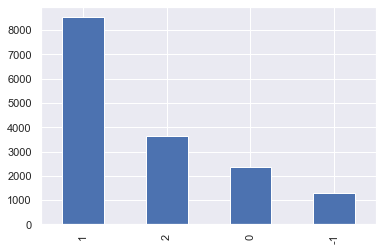

In [11]:
all_train['sentiment'].value_counts().plot(kind = 'bar')
plt.show()

In [12]:
#Removing noise from the train dataset
pattern_url = r'http[s]?://(?:[A-Za-z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9A-Fa-f][0-9A-Fa-f]))+'
subs_url = r'url-web'
all_train['message'] = all_train['message'].replace(to_replace = pattern_url, value = subs_url, regex = True)

In [13]:
#checking the train dataset to see if the noise were removed
all_train.head(20)

,sentiment,message
0,1,PolySciMajor EPA chief doesn't think carbon di...
1,1,It's not like we lack evidence of anthropogeni...
2,2,RT @RawStory: Researchers say we have three ye...
3,1,#TodayinMaker# WIRED : 2016 was a pivotal year...
4,1,"RT @SoyNovioDeTodas: It's 2016, and a racist, ..."
5,1,Worth a read whether you do or don't believe i...
6,1,RT @thenation: Mike Pence doesn’t believe in g...
7,1,RT @makeandmendlife: Six big things we can ALL...
8,1,@AceofSpadesHQ My 8yo nephew is inconsolable. ...
9,1,RT @paigetweedy: no offense… but like… how do ...


In [14]:
#converting all train text to lower case 
all_train['message'] = all_train['message'].str.lower()

In [15]:
#function for removing punctuation
def remove_punctuation(message):
    return ''.join([j for j in message if j not in string.punctuation])

In [16]:
#Removing punctuation from train dataset
all_train['message'] = all_train['message'].apply(remove_punctuation)

In [17]:
#Checking if punctuation from the train dataset has been removed
all_train['message'].iloc[20]

'rt c40cities 46 c40 mayors representing 250m citizens have urged g20 leaders to saveourplanet from climate change you can too…'

In [18]:
#Initialising the tokeniser
tokeniser = TreebankWordTokenizer()

tokenised_tweet = all_train['message'].apply(lambda x: x.split()) #Tokenising the train data

In [19]:
all_train['tokens'] = tokenised_tweet

In [20]:
all_train['tokens'].iloc[4]

['rt',
 'soynoviodetodas',
 'its',
 '2016',
 'and',
 'a',
 'racist',
 'sexist',
 'climate',
 'change',
 'denying',
 'bigot',
 'is',
 'leading',
 'in',
 'the',
 'polls',
 'electionnight']

In [21]:
def remove_stop_words(tokens):    
    return [t for t in tokens if t not in stopwords.words('english')]

In [22]:
%%time
all_train['stem'] = all_train['tokens'].apply(remove_stop_words)

Wall time: 2min 11s


In [23]:
all_train['stem']

0        [polyscimajor, epa, chief, doesnt, think, carb...
1        [like, lack, evidence, anthropogenic, global, ...
2        [rt, rawstory, researchers, say, three, years,...
3        [todayinmaker, wired, 2016, pivotal, year, war...
4        [rt, soynoviodetodas, 2016, racist, sexist, cl...
                               ...                        
15815    [rt, ezlusztig, took, material, global, warmin...
15816    [rt, washingtonpost, climate, change, could, b...
15817    [notiven, rt, nytimesworld, trump, actually, b...
15818    [rt, sara8smiles, hey, liberals, climate, chan...
15819    [rt, chetcannon, kurteichenwalds, climate, cha...
Name: stem, Length: 15820, dtype: object

In [24]:
tokenised_tweet = all_train['stem']

In [25]:
tokenised_tweet

0        [polyscimajor, epa, chief, doesnt, think, carb...
1        [like, lack, evidence, anthropogenic, global, ...
2        [rt, rawstory, researchers, say, three, years,...
3        [todayinmaker, wired, 2016, pivotal, year, war...
4        [rt, soynoviodetodas, 2016, racist, sexist, cl...
                               ...                        
15815    [rt, ezlusztig, took, material, global, warmin...
15816    [rt, washingtonpost, climate, change, could, b...
15817    [notiven, rt, nytimesworld, trump, actually, b...
15818    [rt, sara8smiles, hey, liberals, climate, chan...
15819    [rt, chetcannon, kurteichenwalds, climate, cha...
Name: stem, Length: 15820, dtype: object

In [26]:
#Initialising the stemmer to stem words in the two dataset
stemmer = PorterStemmer()

#stemming the words from the train data
tokenised_tweet = tokenised_tweet.apply(lambda sentence: [stemmer.stem(word) for word in sentence])

In [27]:
tokenised_tweet

0        [polyscimajor, epa, chief, doesnt, think, carb...
1            [like, lack, evid, anthropogen, global, warm]
2        [rt, rawstori, research, say, three, year, act...
3        [todayinmak, wire, 2016, pivot, year, war, cli...
4        [rt, soynoviodetoda, 2016, racist, sexist, cli...
                               ...                        
15815    [rt, ezlusztig, took, materi, global, warm, lg...
15816    [rt, washingtonpost, climat, chang, could, bre...
15817    [notiven, rt, nytimesworld, trump, actual, bel...
15818    [rt, sara8smil, hey, liber, climat, chang, cra...
15819    [rt, chetcannon, kurteichenwald, climat, chang...
Name: stem, Length: 15820, dtype: object

In [28]:
#Initialising the Lemmmatizer
lemmatizer = WordNetLemmatizer()

In [29]:
#Lemmatizing the train data
tokenised_tweet = tokenised_tweet.apply(lambda sentence: [lemmatizer.lemmatize(word) for word in sentence])
tokenised_tweet.head() #Checking to see if Lemmatized

0    [polyscimajor, epa, chief, doesnt, think, carb...
1        [like, lack, evid, anthropogen, global, warm]
2    [rt, rawstori, research, say, three, year, act...
3    [todayinmak, wire, 2016, pivot, year, war, cli...
4    [rt, soynoviodetoda, 2016, racist, sexist, cli...
Name: stem, dtype: object

In [30]:
#combining the cleaned message column into single sentence for the train dataset
for i in range(len(tokenised_tweet)):
    tokenised_tweet[i] = " ".join(tokenised_tweet[i])
all_train['cleaned_tweet'] = tokenised_tweet

In [31]:
all_train.head() #checking to see if well combined into sentence

,sentiment,message,tokens,stem,cleaned_tweet
0,1,polyscimajor epa chief doesnt think carbon dio...,"[polyscimajor, epa, chief, doesnt, think, carb...","[polyscimajor, epa, chief, doesnt, think, carb...",polyscimajor epa chief doesnt think carbon dio...
1,1,its not like we lack evidence of anthropogenic...,"[its, not, like, we, lack, evidence, of, anthr...","[like, lack, evidence, anthropogenic, global, ...",like lack evid anthropogen global warm
2,2,rt rawstory researchers say we have three year...,"[rt, rawstory, researchers, say, we, have, thr...","[rt, rawstory, researchers, say, three, years,...",rt rawstori research say three year act climat...
3,1,todayinmaker wired 2016 was a pivotal year in...,"[todayinmaker, wired, 2016, was, a, pivotal, y...","[todayinmaker, wired, 2016, pivotal, year, war...",todayinmak wire 2016 pivot year war climat cha...
4,1,rt soynoviodetodas its 2016 and a racist sexis...,"[rt, soynoviodetodas, its, 2016, and, a, racis...","[rt, soynoviodetodas, 2016, racist, sexist, cl...",rt soynoviodetoda 2016 racist sexist climat ch...


## TEST DATASET PREPROCESSING

In [32]:
#Removing noise from the test dataset
pattern_url = r'http[s]?://(?:[A-Za-z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9A-Fa-f][0-9A-Fa-f]))+'
subs_url = r'url-web'
df_test['message'] = df_test['message'].replace(to_replace = pattern_url, value = subs_url, regex = True)

In [33]:
#checking the train dataset to see if the noise were removed
df_test.head(20)

,message,tweetid
0,Europe will now be looking to China to make su...,169760
1,Combine this with the polling of staffers re c...,35326
2,"The scary, unimpeachable evidence that climate...",224985
3,@Karoli @morgfair @OsborneInk @dailykos \nPuti...,476263
4,RT @FakeWillMoore: 'Female orgasms cause globa...,872928
5,RT @nycjim: Trump muzzles employees of several...,75639
6,@bmastenbrook yes wrote that in 3rd yr Comp Sc...,211536
7,RT @climatehawk1: Indonesian farmers weather #...,569434
8,RT @guardian: British scientists face a ‘huge ...,315368
9,Aid For Agriculture | Sustainable agriculture ...,591733


In [34]:
#converting all test text to lower case 
df_test['message'] = df_test['message'].str.lower()

In [35]:
#Removing punctuation from test dataset
df_test['message'] = df_test['message'].apply(remove_punctuation)

In [36]:
#Checking if punctuation from the test dataset has been removed
df_test['message'].iloc[4]

'rt fakewillmoore female orgasms cause global warming\nsarcastic republican'

In [37]:
#Tokenising the test data
tokenised_tweet_test = df_test['message'].apply(lambda x: x.split()) #Tokenising the train data

In [38]:
df_test['tokens'] = tokenised_tweet_test

In [39]:
df_test['tokens'].iloc[4]

['rt',
 'fakewillmoore',
 'female',
 'orgasms',
 'cause',
 'global',
 'warming',
 'sarcastic',
 'republican']

In [40]:
# Removing stopwords from the test data
df_test['stem'] = df_test['tokens'].apply(remove_stop_words)

In [41]:
df_test['stem']

0        [europe, looking, china, make, sure, alone, fi...
1        [combine, polling, staffers, climate, change, ...
2        [scary, unimpeachable, evidence, climate, chan...
3        [karoli, morgfair, osborneink, dailykos, putin...
4        [rt, fakewillmoore, female, orgasms, cause, gl...
                               ...                        
10541    [rt, brittanybohrer, brb, writing, poem, clima...
10542    [2016, year, climate, change, came, home, hott...
10543    [rt, loopvanuatu, pacific, countries, positive...
10544    [rt, xanria00018, you’re, hot, must, cause, gl...
10545    [rt, chloebalaoing, climate, change, global, i...
Name: stem, Length: 10546, dtype: object

In [42]:
tokenised_tweet_test = df_test['stem']

In [43]:
#stemming the words from the test data
tokenised_tweet_test = tokenised_tweet_test.apply(lambda sentence: [stemmer.stem(word) for word in sentence])

In [44]:
tokenised_tweet_test

0        [europ, look, china, make, sure, alon, fight, ...
1        [combin, poll, staffer, climat, chang, women, ...
2        [scari, unimpeach, evid, climat, chang, alread...
3        [karoli, morgfair, osborneink, dailyko, putin,...
4        [rt, fakewillmoor, femal, orgasm, caus, global...
                               ...                        
10541    [rt, brittanybohr, brb, write, poem, climat, c...
10542    [2016, year, climat, chang, came, home, hottes...
10543    [rt, loopvanuatu, pacif, countri, posit, fiji,...
10544    [rt, xanria00018, you’r, hot, must, caus, glob...
10545    [rt, chloebalao, climat, chang, global, issu, ...
Name: stem, Length: 10546, dtype: object

In [45]:
#Lemmatizing the test data
tokenised_tweet_test = tokenised_tweet_test.apply(lambda sentence: [lemmatizer.lemmatize(word) for word in sentence])
tokenised_tweet_test.head()

0    [europ, look, china, make, sure, alon, fight, ...
1    [combin, poll, staffer, climat, chang, woman, ...
2    [scari, unimpeach, evid, climat, chang, alread...
3    [karoli, morgfair, osborneink, dailyko, putin,...
4    [rt, fakewillmoor, femal, orgasm, caus, global...
Name: stem, dtype: object

In [46]:
#combining the cleaned message column into single sentence for the test dataset
for j in range(len(tokenised_tweet_test)):
    tokenised_tweet_test[j] = " ".join(tokenised_tweet_test[j])
df_test['cleaned_tweet'] = tokenised_tweet_test

In [47]:
df_test.head() #checking to see if well combined into sentence

,message,tweetid,tokens,stem,cleaned_tweet
0,europe will now be looking to china to make su...,169760,"[europe, will, now, be, looking, to, china, to...","[europe, looking, china, make, sure, alone, fi...",europ look china make sure alon fight climat c...
1,combine this with the polling of staffers re c...,35326,"[combine, this, with, the, polling, of, staffe...","[combine, polling, staffers, climate, change, ...",combin poll staffer climat chang woman right f...
2,the scary unimpeachable evidence that climate ...,224985,"[the, scary, unimpeachable, evidence, that, cl...","[scary, unimpeachable, evidence, climate, chan...",scari unimpeach evid climat chang alreadi urlw...
3,karoli morgfair osborneink dailykos \nputin go...,476263,"[karoli, morgfair, osborneink, dailykos, putin...","[karoli, morgfair, osborneink, dailykos, putin...",karoli morgfair osborneink dailyko putin got j...
4,rt fakewillmoore female orgasms cause global w...,872928,"[rt, fakewillmoore, female, orgasms, cause, gl...","[rt, fakewillmoore, female, orgasms, cause, gl...",rt fakewillmoor femal orgasm caus global warm ...


## EXPLORATORY DATA ANALYSIS

In this section we are going to perform an in-depth analysis of all the variables in the DataFrame. This would give us proper knowledge of our predictor variables to know if they are useful in this project.

In [48]:
#Using NLP to clean this dataset 
sentiment_labels = list(df_train.sentiment.unique())
sentiment_labels

[1, 2, 0, -1]

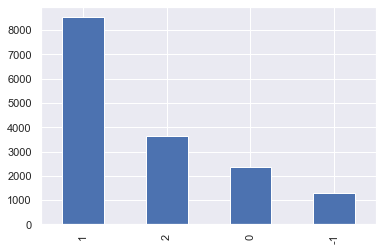

In [49]:
df_train['sentiment'].value_counts().plot(kind = 'bar')
plt.show()

In [50]:
# Separate minority and majority classes
neutral = df_train[df_train['sentiment']==0]
believe = df_train[df_train['sentiment']==1]
not_believe = df_train[df_train['sentiment']== -1]
news = df_train[df_train['sentiment']== 2]

In [51]:
believe_percent = len(believe)/ (len(neutral)+len(believe)+len(not_believe)+len(news))
believe_percent

0.5392249826158417

In [52]:
not_believe_percent = len(not_believe)/ (len(neutral)+len(believe)+len(not_believe)+len(news))
not_believe_percent

0.08192679688981605

In [53]:
neutral = len(neutral)/ (len(neutral)+len(believe)+len(not_believe)+len(news))
neutral

0.1487451798470194

From the above analysis, we can see that the classes in our ressponse variable is not balanced. Therefore we need to balance it during the Data Engineering part of our work.

## VISUALS

In [54]:
## visualising the frequent words
all_words = " ".join([sentence for sentence in all_train['cleaned_tweet']])
wordcloud = WordCloud(width= 800, height = 500, random_state= 42, max_font_size= 100).generate(all_words)

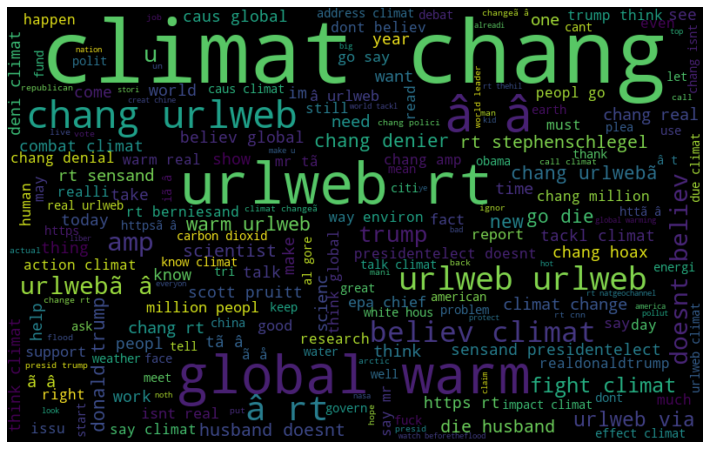

In [55]:
## Ploting the graph
plt.figure(figsize = (15, 8))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

Frequent Words used by believers of climate change

In [56]:
##for frequent words in belief of climate change
all_words = " ".join([sentence for sentence in all_train['cleaned_tweet'][all_train['sentiment']==1]])
wordcloud = WordCloud(width= 800, height = 500, random_state= 42, max_font_size= 100).generate(all_words)

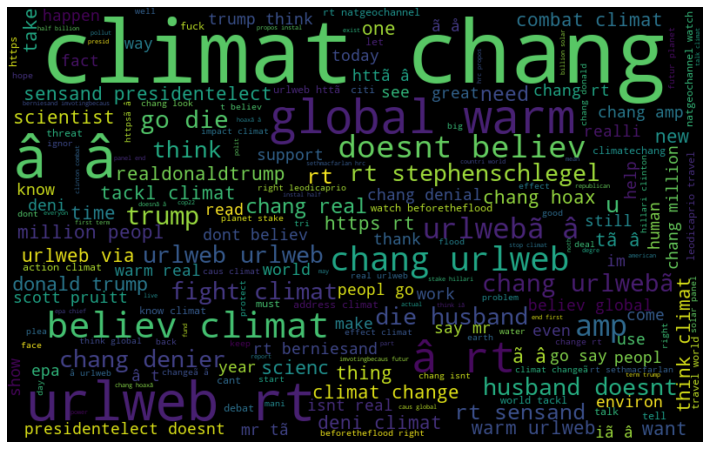

In [57]:
## Ploting the graph
plt.figure(figsize = (15, 8))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

Frequent words used by unbelievers of Climate Change

In [58]:
##for frequent words not in belief of climate change
all_words = " ".join([sentence for sentence in all_train['cleaned_tweet'][all_train['sentiment']==-1]])
wordcloud = WordCloud(width= 800, height = 500, random_state= 42, max_font_size= 100).generate(all_words)

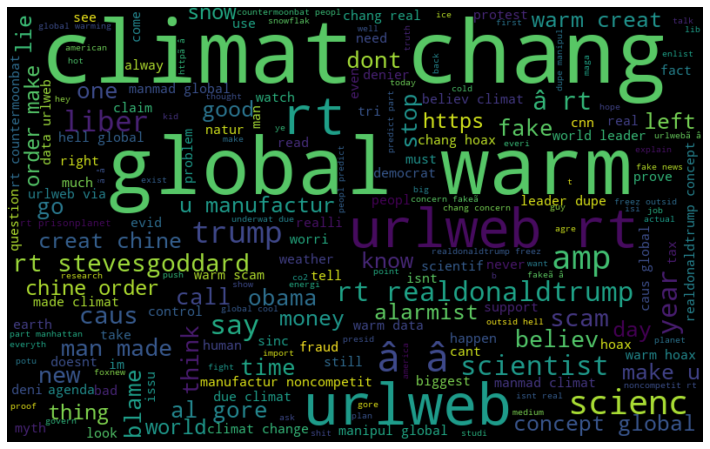

In [59]:
## Ploting the graph
plt.figure(figsize = (15, 8))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

Frequent neutral words

In [60]:
##for frequent words of neutrals of climate change
all_words = " ".join([sentence for sentence in all_train['cleaned_tweet'][all_train['sentiment']==0]])
wordcloud = WordCloud(width= 800, height = 500, random_state= 42, max_font_size= 100).generate(all_words)

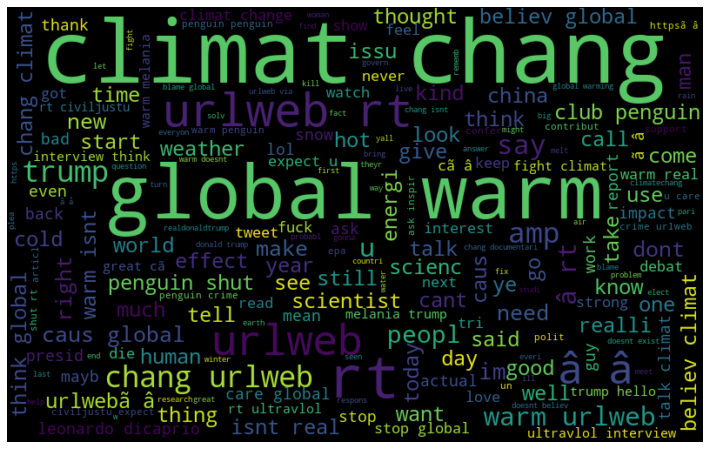

In [61]:
## Ploting the graph
plt.figure(figsize = (15, 8))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

In [62]:
##for frequent words for news of climate change
all_words = " ".join([sentence for sentence in all_train['cleaned_tweet'][all_train['sentiment']==2]])
wordcloud = WordCloud(width= 800, height = 500, random_state= 42, max_font_size= 100).generate(all_words)

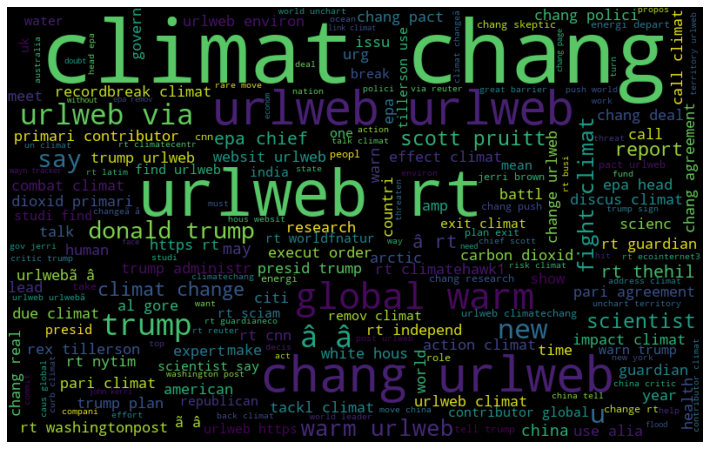

In [63]:
## Ploting the graph
plt.figure(figsize = (15, 8))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

<a id="four"></a>
## 4. Data Engineering
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>

---
    
| ⚡ Description: Data engineering ⚡ |
| :--------------------------- |
| In this section we are going to: clean the dataset, and possibly create new features - as identified in the EDA phase. This is the phase where we drop the features we identified to drop in the EDA phase|
---

In [64]:
#Transforming the cleaned text from the trained data
cv = CountVectorizer(max_features= 10000, ngram_range=(1,2))
bow = cv.fit_transform(all_train['cleaned_tweet'])

In [65]:
#Transforming the cleaned text from the test data
bow_test = cv.transform(df_test['cleaned_tweet'])

In [66]:
#Converting our data
X = bow
X

<15820x10000 sparse matrix of type '<class 'numpy.int64'>'
	with 250408 stored elements in Compressed Sparse Row format>

In [67]:
y = all_train['sentiment']

In [68]:
smt = SMOTE(random_state = 1, k_neighbors = 1)

In [69]:
X,y = smt.fit_resample(X, y)

In [70]:
y.value_counts()

 0    8530
 1    8530
 2    8530
-1    8530
Name: sentiment, dtype: int64

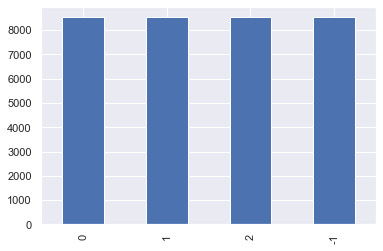

In [71]:
y.value_counts().plot(kind = 'bar')
plt.show()

<a id="five"></a>
## 5. Modelling
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a> 

---

    
| ⚡ Description: Modelling ⚡ |
| :--------------------------- |
| In this section, we created regression models that are able to accurately predict the three hour load shortfall. |

---

## Logistic Regression Model

In [72]:
x_train, x_test, y_train, y_test = train_test_split(X, y, 
random_state = 42, test_size = 0.25)

In [73]:
#Model Training using logistic regression
#model = LogisticRegression(multi_class='ovr')
model = LogisticRegression(random_state=42, solver='lbfgs', multi_class='multinomial')
model.fit(x_train, y_train)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(multi_class='multinomial', random_state=42)

In [74]:
#Testing
pred = model.predict(x_test)

In [75]:
#Predicting the unseen data
model.fit(X, y)
pred_test = model.predict(bow_test)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [76]:
result_model = pd.DataFrame(pred_test, columns= ['sentiment'])
result_model.head(20)

,sentiment
0,1
1,0
2,1
3,0
4,0
5,1
6,1
7,2
8,2
9,1


In [77]:
output = pd.DataFrame({"tweetid":df_test['tweetid']})
submission = output.join(result_model)
submission.to_csv("submission.csv", index = False)

## CatBoost Classification Model

In [78]:
#Model Training using catboost model classifier
rf2_2 = CatBoostClassifier(
                          bootstrap_type="Bernoulli",
                          class_weights=[1, 1, 1, 1],
                          loss_function='MultiClass')

In [79]:
rf2_2.fit(x_train, y_train)

Learning rate set to 0.093354
0:	learn: 1.3368899	total: 383ms	remaining: 6m 22s
1:	learn: 1.2985820	total: 651ms	remaining: 5m 25s
2:	learn: 1.2676562	total: 842ms	remaining: 4m 39s
3:	learn: 1.2404831	total: 966ms	remaining: 4m
4:	learn: 1.2179881	total: 1.07s	remaining: 3m 32s
5:	learn: 1.1975113	total: 1.17s	remaining: 3m 13s
6:	learn: 1.1802261	total: 1.27s	remaining: 3m
7:	learn: 1.1644668	total: 1.38s	remaining: 2m 50s
8:	learn: 1.1519760	total: 1.49s	remaining: 2m 43s
9:	learn: 1.1414114	total: 1.59s	remaining: 2m 37s
10:	learn: 1.1311279	total: 1.69s	remaining: 2m 31s
11:	learn: 1.1224575	total: 1.79s	remaining: 2m 27s
12:	learn: 1.1141913	total: 1.9s	remaining: 2m 24s
13:	learn: 1.1085353	total: 2s	remaining: 2m 20s
14:	learn: 1.1031260	total: 2.13s	remaining: 2m 19s
15:	learn: 1.0973371	total: 2.23s	remaining: 2m 17s
16:	learn: 1.0909603	total: 2.33s	remaining: 2m 14s
17:	learn: 1.0865153	total: 2.44s	remaining: 2m 13s
18:	learn: 1.0826677	total: 2.56s	remaining: 2m 11s
19:	

158:	learn: 0.8816415	total: 17s	remaining: 1m 29s
159:	learn: 0.8810324	total: 17.1s	remaining: 1m 29s
160:	learn: 0.8803115	total: 17.2s	remaining: 1m 29s
161:	learn: 0.8794833	total: 17.3s	remaining: 1m 29s
162:	learn: 0.8787728	total: 17.4s	remaining: 1m 29s
163:	learn: 0.8780618	total: 17.5s	remaining: 1m 29s
164:	learn: 0.8775252	total: 17.7s	remaining: 1m 29s
165:	learn: 0.8768595	total: 17.8s	remaining: 1m 29s
166:	learn: 0.8761388	total: 17.9s	remaining: 1m 29s
167:	learn: 0.8752941	total: 18s	remaining: 1m 29s
168:	learn: 0.8745360	total: 18.1s	remaining: 1m 29s
169:	learn: 0.8737011	total: 18.2s	remaining: 1m 28s
170:	learn: 0.8730105	total: 18.3s	remaining: 1m 28s
171:	learn: 0.8722728	total: 18.4s	remaining: 1m 28s
172:	learn: 0.8716297	total: 18.5s	remaining: 1m 28s
173:	learn: 0.8709346	total: 18.6s	remaining: 1m 28s
174:	learn: 0.8697126	total: 18.7s	remaining: 1m 28s
175:	learn: 0.8690632	total: 18.8s	remaining: 1m 27s
176:	learn: 0.8681307	total: 18.9s	remaining: 1m 2

316:	learn: 0.7973507	total: 32.9s	remaining: 1m 10s
317:	learn: 0.7968163	total: 33s	remaining: 1m 10s
318:	learn: 0.7965254	total: 33.1s	remaining: 1m 10s
319:	learn: 0.7963272	total: 33.2s	remaining: 1m 10s
320:	learn: 0.7959759	total: 33.3s	remaining: 1m 10s
321:	learn: 0.7955915	total: 33.4s	remaining: 1m 10s
322:	learn: 0.7953054	total: 33.5s	remaining: 1m 10s
323:	learn: 0.7948945	total: 33.6s	remaining: 1m 10s
324:	learn: 0.7946780	total: 33.7s	remaining: 1m 9s
325:	learn: 0.7940825	total: 33.8s	remaining: 1m 9s
326:	learn: 0.7939114	total: 33.9s	remaining: 1m 9s
327:	learn: 0.7936357	total: 34s	remaining: 1m 9s
328:	learn: 0.7933845	total: 34.1s	remaining: 1m 9s
329:	learn: 0.7930543	total: 34.2s	remaining: 1m 9s
330:	learn: 0.7926901	total: 34.3s	remaining: 1m 9s
331:	learn: 0.7923473	total: 34.4s	remaining: 1m 9s
332:	learn: 0.7918679	total: 34.5s	remaining: 1m 9s
333:	learn: 0.7916232	total: 34.6s	remaining: 1m 9s
334:	learn: 0.7914100	total: 34.7s	remaining: 1m 8s
335:	lea

475:	learn: 0.7495766	total: 48.1s	remaining: 53s
476:	learn: 0.7493412	total: 48.2s	remaining: 52.9s
477:	learn: 0.7490620	total: 48.3s	remaining: 52.8s
478:	learn: 0.7487100	total: 48.4s	remaining: 52.6s
479:	learn: 0.7483413	total: 48.5s	remaining: 52.5s
480:	learn: 0.7482246	total: 48.6s	remaining: 52.4s
481:	learn: 0.7479214	total: 48.7s	remaining: 52.3s
482:	learn: 0.7476883	total: 48.8s	remaining: 52.2s
483:	learn: 0.7475424	total: 48.9s	remaining: 52.1s
484:	learn: 0.7472456	total: 49s	remaining: 52s
485:	learn: 0.7467441	total: 49.1s	remaining: 51.9s
486:	learn: 0.7465721	total: 49.2s	remaining: 51.8s
487:	learn: 0.7464202	total: 49.2s	remaining: 51.7s
488:	learn: 0.7461362	total: 49.3s	remaining: 51.6s
489:	learn: 0.7457985	total: 49.4s	remaining: 51.5s
490:	learn: 0.7455155	total: 49.5s	remaining: 51.4s
491:	learn: 0.7452423	total: 49.6s	remaining: 51.3s
492:	learn: 0.7449128	total: 49.8s	remaining: 51.2s
493:	learn: 0.7447110	total: 49.8s	remaining: 51.1s
494:	learn: 0.7445

635:	learn: 0.7160612	total: 1m 6s	remaining: 37.9s
636:	learn: 0.7158079	total: 1m 6s	remaining: 37.9s
637:	learn: 0.7156690	total: 1m 6s	remaining: 37.8s
638:	learn: 0.7156022	total: 1m 6s	remaining: 37.6s
639:	learn: 0.7155074	total: 1m 6s	remaining: 37.5s
640:	learn: 0.7152795	total: 1m 6s	remaining: 37.5s
641:	learn: 0.7152165	total: 1m 7s	remaining: 37.4s
642:	learn: 0.7150934	total: 1m 7s	remaining: 37.3s
643:	learn: 0.7149798	total: 1m 7s	remaining: 37.1s
644:	learn: 0.7149023	total: 1m 7s	remaining: 37s
645:	learn: 0.7147491	total: 1m 7s	remaining: 36.9s
646:	learn: 0.7145957	total: 1m 7s	remaining: 36.9s
647:	learn: 0.7144707	total: 1m 7s	remaining: 36.7s
648:	learn: 0.7144011	total: 1m 7s	remaining: 36.6s
649:	learn: 0.7141771	total: 1m 7s	remaining: 36.5s
650:	learn: 0.7140599	total: 1m 7s	remaining: 36.5s
651:	learn: 0.7139840	total: 1m 8s	remaining: 36.3s
652:	learn: 0.7138124	total: 1m 8s	remaining: 36.2s
653:	learn: 0.7136238	total: 1m 8s	remaining: 36.1s
654:	learn: 0.

791:	learn: 0.6916574	total: 1m 24s	remaining: 22.1s
792:	learn: 0.6915240	total: 1m 24s	remaining: 22s
793:	learn: 0.6913495	total: 1m 24s	remaining: 21.9s
794:	learn: 0.6911329	total: 1m 24s	remaining: 21.8s
795:	learn: 0.6909569	total: 1m 24s	remaining: 21.7s
796:	learn: 0.6908905	total: 1m 24s	remaining: 21.6s
797:	learn: 0.6907933	total: 1m 24s	remaining: 21.5s
798:	learn: 0.6902926	total: 1m 24s	remaining: 21.4s
799:	learn: 0.6900524	total: 1m 25s	remaining: 21.3s
800:	learn: 0.6898929	total: 1m 25s	remaining: 21.2s
801:	learn: 0.6896605	total: 1m 25s	remaining: 21.1s
802:	learn: 0.6895796	total: 1m 25s	remaining: 20.9s
803:	learn: 0.6893962	total: 1m 25s	remaining: 20.8s
804:	learn: 0.6893455	total: 1m 25s	remaining: 20.7s
805:	learn: 0.6892153	total: 1m 25s	remaining: 20.6s
806:	learn: 0.6891498	total: 1m 25s	remaining: 20.5s
807:	learn: 0.6890483	total: 1m 25s	remaining: 20.4s
808:	learn: 0.6890003	total: 1m 25s	remaining: 20.3s
809:	learn: 0.6888750	total: 1m 26s	remaining: 2

948:	learn: 0.6707776	total: 1m 42s	remaining: 5.49s
949:	learn: 0.6704354	total: 1m 42s	remaining: 5.38s
950:	learn: 0.6703740	total: 1m 42s	remaining: 5.27s
951:	learn: 0.6702216	total: 1m 42s	remaining: 5.17s
952:	learn: 0.6700913	total: 1m 42s	remaining: 5.06s
953:	learn: 0.6700110	total: 1m 42s	remaining: 4.96s
954:	learn: 0.6699020	total: 1m 42s	remaining: 4.85s
955:	learn: 0.6697580	total: 1m 42s	remaining: 4.74s
956:	learn: 0.6695423	total: 1m 43s	remaining: 4.63s
957:	learn: 0.6694150	total: 1m 43s	remaining: 4.52s
958:	learn: 0.6692266	total: 1m 43s	remaining: 4.42s
959:	learn: 0.6690224	total: 1m 43s	remaining: 4.31s
960:	learn: 0.6687718	total: 1m 43s	remaining: 4.2s
961:	learn: 0.6686085	total: 1m 43s	remaining: 4.1s
962:	learn: 0.6685384	total: 1m 43s	remaining: 3.99s
963:	learn: 0.6684602	total: 1m 43s	remaining: 3.88s
964:	learn: 0.6683661	total: 1m 44s	remaining: 3.78s
965:	learn: 0.6683306	total: 1m 44s	remaining: 3.67s
966:	learn: 0.6682665	total: 1m 44s	remaining: 3

In [80]:
#Testing
y_pred = rf2_2.predict(x_test)

In [81]:
rf2_2.fit(x_train, y_train)

Learning rate set to 0.093354
0:	learn: 1.3368899	total: 98.7ms	remaining: 1m 38s
1:	learn: 1.2985820	total: 207ms	remaining: 1m 43s
2:	learn: 1.2676562	total: 337ms	remaining: 1m 52s
3:	learn: 1.2404831	total: 454ms	remaining: 1m 53s
4:	learn: 1.2179881	total: 562ms	remaining: 1m 51s
5:	learn: 1.1975113	total: 690ms	remaining: 1m 54s
6:	learn: 1.1802261	total: 830ms	remaining: 1m 57s
7:	learn: 1.1644668	total: 955ms	remaining: 1m 58s
8:	learn: 1.1519760	total: 1.11s	remaining: 2m 1s
9:	learn: 1.1414114	total: 1.25s	remaining: 2m 3s
10:	learn: 1.1311279	total: 1.36s	remaining: 2m 2s
11:	learn: 1.1224575	total: 1.47s	remaining: 2m
12:	learn: 1.1141913	total: 1.57s	remaining: 1m 58s
13:	learn: 1.1085353	total: 1.68s	remaining: 1m 58s
14:	learn: 1.1031260	total: 1.79s	remaining: 1m 57s
15:	learn: 1.0973371	total: 1.91s	remaining: 1m 57s
16:	learn: 1.0909603	total: 2.07s	remaining: 1m 59s
17:	learn: 1.0865153	total: 2.19s	remaining: 1m 59s
18:	learn: 1.0826677	total: 2.3s	remaining: 1m 58s

158:	learn: 0.8816415	total: 20.4s	remaining: 1m 47s
159:	learn: 0.8810324	total: 20.5s	remaining: 1m 47s
160:	learn: 0.8803115	total: 20.6s	remaining: 1m 47s
161:	learn: 0.8794833	total: 20.7s	remaining: 1m 46s
162:	learn: 0.8787728	total: 20.8s	remaining: 1m 46s
163:	learn: 0.8780618	total: 20.8s	remaining: 1m 46s
164:	learn: 0.8775252	total: 21s	remaining: 1m 46s
165:	learn: 0.8768595	total: 21.1s	remaining: 1m 45s
166:	learn: 0.8761388	total: 21.2s	remaining: 1m 45s
167:	learn: 0.8752941	total: 21.3s	remaining: 1m 45s
168:	learn: 0.8745360	total: 21.4s	remaining: 1m 45s
169:	learn: 0.8737011	total: 21.5s	remaining: 1m 45s
170:	learn: 0.8730105	total: 21.7s	remaining: 1m 45s
171:	learn: 0.8722728	total: 21.8s	remaining: 1m 45s
172:	learn: 0.8716297	total: 21.9s	remaining: 1m 44s
173:	learn: 0.8709346	total: 22.1s	remaining: 1m 44s
174:	learn: 0.8697126	total: 22.2s	remaining: 1m 44s
175:	learn: 0.8690632	total: 22.4s	remaining: 1m 44s
176:	learn: 0.8681307	total: 22.5s	remaining: 1m

314:	learn: 0.7982976	total: 37.6s	remaining: 1m 21s
315:	learn: 0.7976347	total: 37.7s	remaining: 1m 21s
316:	learn: 0.7973507	total: 37.8s	remaining: 1m 21s
317:	learn: 0.7968163	total: 37.9s	remaining: 1m 21s
318:	learn: 0.7965254	total: 38s	remaining: 1m 21s
319:	learn: 0.7963272	total: 38.1s	remaining: 1m 21s
320:	learn: 0.7959759	total: 38.2s	remaining: 1m 20s
321:	learn: 0.7955915	total: 38.3s	remaining: 1m 20s
322:	learn: 0.7953054	total: 38.4s	remaining: 1m 20s
323:	learn: 0.7948945	total: 38.6s	remaining: 1m 20s
324:	learn: 0.7946780	total: 38.7s	remaining: 1m 20s
325:	learn: 0.7940825	total: 38.8s	remaining: 1m 20s
326:	learn: 0.7939114	total: 38.9s	remaining: 1m 20s
327:	learn: 0.7936357	total: 39s	remaining: 1m 19s
328:	learn: 0.7933845	total: 39.1s	remaining: 1m 19s
329:	learn: 0.7930543	total: 39.2s	remaining: 1m 19s
330:	learn: 0.7926901	total: 39.3s	remaining: 1m 19s
331:	learn: 0.7923473	total: 39.4s	remaining: 1m 19s
332:	learn: 0.7918679	total: 39.6s	remaining: 1m 1

471:	learn: 0.7505520	total: 53.5s	remaining: 59.9s
472:	learn: 0.7504059	total: 53.6s	remaining: 59.7s
473:	learn: 0.7500692	total: 53.7s	remaining: 59.6s
474:	learn: 0.7498000	total: 53.8s	remaining: 59.5s
475:	learn: 0.7495766	total: 53.9s	remaining: 59.4s
476:	learn: 0.7493412	total: 54s	remaining: 59.3s
477:	learn: 0.7490620	total: 54.1s	remaining: 59.1s
478:	learn: 0.7487100	total: 54.2s	remaining: 59s
479:	learn: 0.7483413	total: 54.3s	remaining: 58.8s
480:	learn: 0.7482246	total: 54.4s	remaining: 58.7s
481:	learn: 0.7479214	total: 54.5s	remaining: 58.6s
482:	learn: 0.7476883	total: 54.6s	remaining: 58.4s
483:	learn: 0.7475424	total: 54.7s	remaining: 58.3s
484:	learn: 0.7472456	total: 54.8s	remaining: 58.2s
485:	learn: 0.7467441	total: 54.9s	remaining: 58.1s
486:	learn: 0.7465721	total: 55s	remaining: 57.9s
487:	learn: 0.7464202	total: 55.1s	remaining: 57.8s
488:	learn: 0.7461362	total: 55.2s	remaining: 57.6s
489:	learn: 0.7457985	total: 55.3s	remaining: 57.5s
490:	learn: 0.7455

631:	learn: 0.7168483	total: 1m 10s	remaining: 40.8s
632:	learn: 0.7166548	total: 1m 10s	remaining: 40.7s
633:	learn: 0.7164101	total: 1m 10s	remaining: 40.6s
634:	learn: 0.7162239	total: 1m 10s	remaining: 40.5s
635:	learn: 0.7160612	total: 1m 10s	remaining: 40.4s
636:	learn: 0.7158079	total: 1m 10s	remaining: 40.3s
637:	learn: 0.7156690	total: 1m 10s	remaining: 40.2s
638:	learn: 0.7156022	total: 1m 11s	remaining: 40.1s
639:	learn: 0.7155074	total: 1m 11s	remaining: 40s
640:	learn: 0.7152795	total: 1m 11s	remaining: 39.9s
641:	learn: 0.7152165	total: 1m 11s	remaining: 39.8s
642:	learn: 0.7150934	total: 1m 11s	remaining: 39.7s
643:	learn: 0.7149798	total: 1m 11s	remaining: 39.5s
644:	learn: 0.7149023	total: 1m 11s	remaining: 39.4s
645:	learn: 0.7147491	total: 1m 11s	remaining: 39.3s
646:	learn: 0.7145957	total: 1m 11s	remaining: 39.2s
647:	learn: 0.7144707	total: 1m 11s	remaining: 39.1s
648:	learn: 0.7144011	total: 1m 12s	remaining: 39s
649:	learn: 0.7141771	total: 1m 12s	remaining: 38.

788:	learn: 0.6920710	total: 1m 27s	remaining: 23.4s
789:	learn: 0.6918246	total: 1m 27s	remaining: 23.3s
790:	learn: 0.6917758	total: 1m 27s	remaining: 23.2s
791:	learn: 0.6916574	total: 1m 27s	remaining: 23.1s
792:	learn: 0.6915240	total: 1m 28s	remaining: 23s
793:	learn: 0.6913495	total: 1m 28s	remaining: 22.9s
794:	learn: 0.6911329	total: 1m 28s	remaining: 22.8s
795:	learn: 0.6909569	total: 1m 28s	remaining: 22.7s
796:	learn: 0.6908905	total: 1m 28s	remaining: 22.6s
797:	learn: 0.6907933	total: 1m 28s	remaining: 22.5s
798:	learn: 0.6902926	total: 1m 28s	remaining: 22.3s
799:	learn: 0.6900524	total: 1m 28s	remaining: 22.2s
800:	learn: 0.6898929	total: 1m 29s	remaining: 22.1s
801:	learn: 0.6896605	total: 1m 29s	remaining: 22s
802:	learn: 0.6895796	total: 1m 29s	remaining: 21.9s
803:	learn: 0.6893962	total: 1m 29s	remaining: 21.8s
804:	learn: 0.6893455	total: 1m 29s	remaining: 21.7s
805:	learn: 0.6892153	total: 1m 29s	remaining: 21.6s
806:	learn: 0.6891498	total: 1m 29s	remaining: 21.

944:	learn: 0.6712539	total: 1m 44s	remaining: 6.1s
945:	learn: 0.6711729	total: 1m 44s	remaining: 5.99s
946:	learn: 0.6710952	total: 1m 45s	remaining: 5.88s
947:	learn: 0.6710289	total: 1m 45s	remaining: 5.76s
948:	learn: 0.6707776	total: 1m 45s	remaining: 5.65s
949:	learn: 0.6704354	total: 1m 45s	remaining: 5.54s
950:	learn: 0.6703740	total: 1m 45s	remaining: 5.43s
951:	learn: 0.6702216	total: 1m 45s	remaining: 5.32s
952:	learn: 0.6700913	total: 1m 45s	remaining: 5.21s
953:	learn: 0.6700110	total: 1m 45s	remaining: 5.09s
954:	learn: 0.6699020	total: 1m 45s	remaining: 4.98s
955:	learn: 0.6697580	total: 1m 45s	remaining: 4.87s
956:	learn: 0.6695423	total: 1m 45s	remaining: 4.76s
957:	learn: 0.6694150	total: 1m 46s	remaining: 4.65s
958:	learn: 0.6692266	total: 1m 46s	remaining: 4.54s
959:	learn: 0.6690224	total: 1m 46s	remaining: 4.43s
960:	learn: 0.6687718	total: 1m 46s	remaining: 4.32s
961:	learn: 0.6686085	total: 1m 46s	remaining: 4.21s
962:	learn: 0.6685384	total: 1m 46s	remaining: 

In [82]:
y_pred_test = rf2_2.predict(bow_test)

In [83]:
result_cat = pd.DataFrame(y_pred_test, columns= ['sentiment'])
result_cat.head(20)

,sentiment
0,1
1,2
2,1
3,1
4,0
5,1
6,1
7,1
8,2
9,1


In [84]:
output = pd.DataFrame({"tweetid":df_test['tweetid']})
submission_cat = output.join(result_model)
submission_cat.to_csv("submission_cat.csv", index = False)

## Decision Tree Classification Model

In [85]:
#Classification
tree = DecisionTreeClassifier(random_state=42)

In [86]:
tree.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [87]:
tree_pred = tree.predict(x_test)

In [88]:
tree.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [89]:
tree_pred_test = tree.predict(bow_test)

In [90]:
result_tree = pd.DataFrame(tree_pred_test, columns= ['sentiment'])
result_tree.head(20)

,sentiment
0,1
1,1
2,0
3,1
4,0
5,1
6,-1
7,1
8,2
9,2


In [91]:
output = pd.DataFrame({"tweetid":df_test['tweetid']})
submission_tree = output.join(result_tree)
submission_tree.to_csv("submission_tree.csv", index = False)

## Support Vector Machine

In [92]:
svc = SVC(kernel='rbf')
svc.fit(x_train, y_train)

SVC()

In [93]:
svc_pred = svc.predict(x_test)

In [94]:
svc.fit(x_train,y_train)
svc_pred_test = svc.predict(bow_test)

In [95]:
result_svc = pd.DataFrame(svc_pred_test, columns= ['sentiment'])
result_svc.head(20)

,sentiment
0,1
1,0
2,1
3,1
4,0
5,1
6,1
7,1
8,2
9,1


In [96]:
output = pd.DataFrame({"tweetid":df_test['tweetid']})
submission_svc = output.join(result_svc)
submission_svc.to_csv("submission_svc.csv", index = False)

## Voting Ensemble Classification Model

In [97]:
model_ensemble = VotingClassifier(estimators=[('lr', model), ('dt', tree), ("svm", svc)], voting='hard')

In [98]:
model_ensemble.fit(x_train,y_train)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('lr',
                              LogisticRegression(multi_class='multinomial',
                                                 random_state=42)),
                             ('dt', DecisionTreeClassifier(random_state=42)),
                             ('svm', SVC())])

In [99]:
ensmb_pred = model_ensemble.predict(x_test)

In [100]:
model_ensemble.fit(x_train,y_train)
esmb_pred_test = model_ensemble.predict(bow_test)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [101]:
result_esmb = pd.DataFrame(esmb_pred_test, columns= ['sentiment'])
result_esmb.head(20)

,sentiment
0,1
1,0
2,1
3,1
4,0
5,1
6,1
7,1
8,2
9,1


In [102]:
output = pd.DataFrame({"tweetid":df_test['tweetid']})
submission_esmb = output.join(result_esmb)
submission_esmb.to_csv("submission_esmb.csv", index = False)

## XGBOOST CLASSIFICATION MODEL

In [103]:
# fit model no training data
model_xgb = XGBClassifier()
model_xgb.fit(x_train, y_train)

XGBClassifier(objective='multi:softprob')

In [104]:
xgb_pred = model_xgb.predict(x_test)

In [105]:
model_xgb.fit(x_train,y_train)
xgb_pred_test = model_xgb.predict(bow_test)

In [106]:
result_xgb = pd.DataFrame(xgb_pred_test, columns= ['sentiment'])
result_xgb.head(20)

,sentiment
0,1
1,2
2,2
3,1
4,0
5,2
6,1
7,2
8,2
9,2


In [107]:
output = pd.DataFrame({"tweetid":df_test['tweetid']})
submission_xgb = output.join(result_xgb)
submission_xgb.to_csv("submission_xgb.csv", index = False)

<a id="six"></a>
## 6. Model Performance
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>

---
    
| ⚡ Description: Model performance ⚡ |
| :--------------------------- |
| In this section the relative performance of the various trained ML models on a holdout dataset was carried out. 
---

In [108]:
#Checking Logistics Regression model performance
def get_class_report(y_test, y_predict):
    #your code here
    accuracy = classification_report(y_test, y_predict)
    return accuracy

In [109]:
#Checking Logistics Regression model performance
print(get_class_report(y_test, pred))

              precision    recall  f1-score   support

          -1       0.74      0.77      0.75      2092
           0       0.66      0.58      0.62      2102
           1       0.81      0.80      0.80      2132
           2       0.79      0.87      0.83      2204

    accuracy                           0.75      8530
   macro avg       0.75      0.75      0.75      8530
weighted avg       0.75      0.75      0.75      8530



In [110]:
#Checking Catboost Classification model performance
print(get_class_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.70      0.72      0.71      2092
           0       0.66      0.57      0.61      2102
           1       0.79      0.74      0.76      2132
           2       0.73      0.85      0.79      2204

    accuracy                           0.72      8530
   macro avg       0.72      0.72      0.72      8530
weighted avg       0.72      0.72      0.72      8530



In [111]:
#Checking Decision Tree Classification model performance
print(get_class_report(y_test, tree_pred))

              precision    recall  f1-score   support

          -1       0.69      0.85      0.76      2092
           0       0.66      0.66      0.66      2102
           1       0.76      0.64      0.69      2132
           2       0.81      0.76      0.78      2204

    accuracy                           0.73      8530
   macro avg       0.73      0.73      0.72      8530
weighted avg       0.73      0.73      0.72      8530



In [112]:
#Checking Support Vector Machine Classification model performance
print(get_class_report(y_test, svc_pred))

              precision    recall  f1-score   support

          -1       0.75      0.76      0.76      2092
           0       0.73      0.64      0.68      2102
           1       0.76      0.86      0.81      2132
           2       0.84      0.82      0.83      2204

    accuracy                           0.77      8530
   macro avg       0.77      0.77      0.77      8530
weighted avg       0.77      0.77      0.77      8530



In [113]:
#Checking voting ensemble classification model performance
print(get_class_report(y_test, ensmb_pred))

              precision    recall  f1-score   support

          -1       0.75      0.81      0.78      2092
           0       0.74      0.68      0.71      2102
           1       0.79      0.82      0.81      2132
           2       0.86      0.82      0.84      2204

    accuracy                           0.78      8530
   macro avg       0.78      0.78      0.78      8530
weighted avg       0.78      0.78      0.78      8530



In [114]:
#Checking xgboost classification model performance
print(get_class_report(y_test, xgb_pred))

              precision    recall  f1-score   support

          -1       0.87      0.67      0.76      2092
           0       0.59      0.57      0.58      2102
           1       0.65      0.60      0.63      2132
           2       0.65      0.87      0.75      2204

    accuracy                           0.68      8530
   macro avg       0.69      0.68      0.68      8530
weighted avg       0.69      0.68      0.68      8530



<a id="seven"></a>
## 7. Model Explanations
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>

---
    
| ⚡ Description: Model explanation ⚡ |
| :--------------------------- |
| In this section, you are required to discuss how the best performing model works in a simple way so that both technical and non-technical stakeholders can grasp the intuition behind the model's inner workings. |

---

<a id="seven"></a>
## 8. Conclusion
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>

---
    
| ⚡ Description: Model explanation ⚡ |
| :--------------------------- |
| In this section, you are required to discuss how the best performing model works in a simple way so that both technical and non-technical stakeholders can grasp the intuition behind the model's inner workings. |

---